In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle
import scipy

from scipy.optimize import curve_fit

from scipy.integrate import quad

In [3]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [4]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [46]:

odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [6]:
#odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-group_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)

In [76]:
#odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10_dk0_kmax10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10_1 = pickle.load(f)

In [93]:
#odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-group_logM10_dk0_kmax10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10_1 = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '../ps_data/snap40/mvir/ps-intensity-group_logM10_dk0_kmax10.pickle'

In [7]:
from nbodykit.lab import cosmology as n_cosmology
c      = n_cosmology.Planck15
c = c.clone(P_k_max=100)
#c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
#Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')

Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [8]:
def cf_nl_w_bias(r, bias=1, R=None):
    bias_factor=bias**2
    cf = bias_factor*cf_nl(r)
    return cf

In [9]:
def cf_nl_excl(r, bias=1, R=0.15):
    d = 2*R
    mask = r < d
    bias_factor=bias**2
    cf = bias_factor*cf_nl(r)
    cf[mask] = -1
    return cf

In [10]:
def lognormal_cf(xi_c, sigma, R,bias=1, rmax=3, dr=0.1):
    #dr = 0.00003
    Nr = int( rmax / dr )
  
    r_list = np.array([ dr * (i+1) for i in range(Nr) ])
    
    d = 2*R
    x = np.log10(r_list / d) / (np.sqrt(2) * sigma)
    fr = 1 - 0.5 * (1.0 + scipy.special.erf(x))
    if sigma == 0:
        xi_d = xi_c(r_list,bias=bias)
    else:
        xi_d = (1 - fr) * (xi_c(r_list, bias=bias) + 1) - 1

    return xi_d

In [11]:
def pk_from_cf(logks):
    rmax = 100
    dr=0.01
    r_list = np.arange(1e-4,rmax,dr)
    cf = lognormal_cf(cf_nl_w_bias, sigma=0.17, R=0.37, bias=2, rmax=rmax, dr=dr)
    
    k_list = 10**np.array(logks)
    Pk = np.zeros(len(k_list))
    prefactor = dr * 4. * np.pi
    for i, k in enumerate(k_list):
        sin_term = np.sin(k * r_list) / (k * r_list)
        Pk[i] = np.sum(prefactor * r_list**2 * sin_term * cf)


    return Pk

In [12]:
def pk_from_cf_nl(logks):
    rmax = 1000
    dr=0.1
    r_list = np.arange(1e-4,rmax,dr)
    cf = cf_nl_excl(r_list, bias=2, R=0.37)
    
    k_list = 10**np.array(logks)
    Pk = np.zeros(len(k_list))
    prefactor = dr * 4. * np.pi
    for i, k in enumerate(k_list):
        sin_term = np.sin(k * r_list) / (k * r_list)
        Pk[i] = np.sum(prefactor * r_list**2 * sin_term * cf)


    return Pk

In [13]:
logks_tng = np.log10(Pk_gal10["k"])
ks_tng = Pk_gal10["k"]
coef_k = (ks_tng**3)/(2*np.pi**2)

In [14]:
pk_fit = pk_from_cf(logks_tng)

In [15]:
popt = np.array([6.16619035e+14, 3.64190401e-03, 5.00000000e-01, 1.05736681e+00])

In [16]:
def nfw_profile(r, rho0, rs):
    return rho0 / ((r / rs) * (1 + r / rs)**2)

def rho_s(mvir, r_s, c):
    rhos = (mvir/(4*np.pi*r_s**3))*(np.log(1+c) - c/(1+c))**-1
    return rhos
    
def nfw_ft_numerical(k_values, rho0, rs, rvir, rmax):

    def integrand_func(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rho0, rs) * np.sin(k * r) / (k * r)
        return integrand

    def integrand_norm(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rho0, rs)
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [17]:
uk = nfw_ft_numerical(ks_tng, *popt)

In [18]:
shot_gal = Pk_gal10.attrs["shotnoise"]
shot_halo = Pk_sum10.attrs["shotnoise"]
model_1halo = (uk**2 * (shot_halo - shot_gal)) + shot_gal

In [19]:
tng_1halo = np.log10((Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])))
tng_2halo = np.log10((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]))
tng_tot = np.log10((Pk_gal10["power"].real))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in log10
  


In [99]:
nmodes = Pk_gal10["modes"]
err_gal_up = np.log10(Pk_gal10["power"].real + Pk_gal10["power"].real/np.sqrt(nmodes)) -  np.log10(Pk_gal10["power"].real)
err_gal_down = np.log10(Pk_gal10["power"].real) - np.log10(Pk_gal10["power"].real - Pk_gal10["power"].real/np.sqrt(nmodes))


In [43]:
logks_tng[:5]

array([-1.36238137, -1.06033514, -0.85899556, -0.72547219, -0.62661139])

In [42]:
nmodes[:5]

array([  26,  152,  440,  738, 1160])

In [94]:
nmodes1 = Pk_gal10_1["modes"]
print(nmodes1)

[   1    6   12 ... 1424    0  592]


In [80]:
logks_1 = np.log10(Pk_gal10_1["k"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


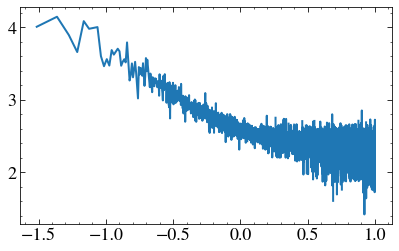

In [77]:
plt.plot(np.log10(Pk_gal10_1["k"]), np.log10(Pk_gal10_1["power"].real))

In [106]:
bin_edges = np.arange(-1.5,1.35, 0.25)
bin_centers = (bin_edges[:-1] +  bin_edges[1:])/2
mean_list = []

for i, edge in enumerate(bin_edges[:-1]):
    mask = (logks_1 > edge) & (logks_1 < bin_edges[i+1])
    mean = np.sum(Pk_gal10_1["power"].real[mask]*nmodes1[mask])/np.sum(nmodes1[mask])

    if edge >= 1:
        print(edge)
        mask = (logks_tng > edge) & (logks_tng < bin_edges[i+1])
        
        mean = np.sum(Pk_gal10["power"].real[mask]*nmodes[mask])/np.sum(nmodes[mask])

    mean_list.append(mean)

1.0


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:7: RuntimeWarning: invalid value encountered in double_scalars
  import sys


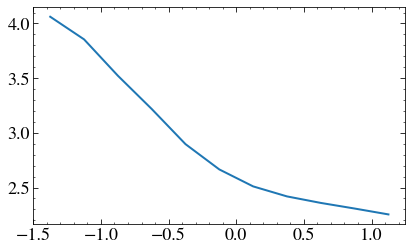

In [107]:
plt.plot(bin_centers, np.log10(mean_list))

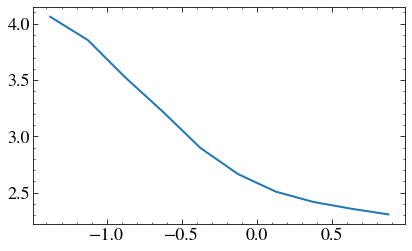

In [96]:
plt.plot(bin_centers, np.log10(mean_list))

In [87]:
np.arange(-1.5, -0.6)

array([-1.5])

In [88]:
mask = logks_tng > -0.9
logks1 = logks_tng[~mask]
logks2 = logks_tng[mask]

tng_1halo1 = tng_1halo[~mask]
tng_1halo2 = tng_1halo[mask]
tng_2halo1 = tng_2halo[~mask]
tng_2halo2 = tng_2halo[mask]

tng_tot1 = tng_tot[~mask]
tng_tot2 = tng_tot[mask]



start = 0
step = 1
result = []
spaced_2halo = []

spaced_tot = []

logks_new = []
logks_tot = []
while start < len(tng_1halo2):
    
    result.append(tng_1halo2[start])
    spaced_2halo.append(tng_2halo2[start])
    spaced_tot.append(tng_tot2[start])
    
    logks_new.append(logks2[start])

    logks_tot.append(logks_tng[start])
    start += step
    step += 3  # Increase step width
    if start > 10:
        step += 5

result = np.array(result)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in log10


Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

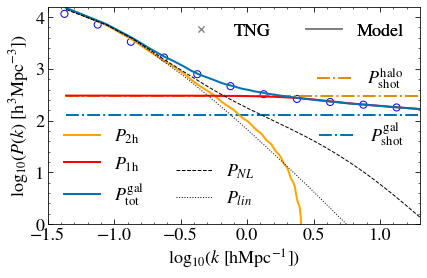

In [108]:

plt.plot(logks_tng, [np.log10((Pk_gal10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{\mathrm{gal}}_{\mathrm{shot}}$", linestyle="dashdot", c=palette_tab10[0])
plt.plot(logks_tng, [np.log10((Pk_sum10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{\mathrm{halo}}_{\mathrm{shot}}$", linestyle="dashdot", c=palette_tab10[1])

#plt.scatter(logks_tng, np.log10((Pk_gal10["power"].real)), label="$P^{\mathrm{gal}}_{\mathrm{tot}}$", s=50, facecolors='none', edgecolors=palette_tab10[0])

#plt.scatter(logks_tng, np.log10((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])), label="$P_{\mathrm{2h}}$", s=50, facecolors='none', edgecolors=palette_tab10[1])

# plt.scatter(logks1,tng_tot1,  marker="x", s=100, c=palette_tab10[0])
# plt.scatter(logks_new, spaced_tot, marker="x", s=100, c=palette_tab10[0])
# plt.scatter(logks1,tng_2halo1, s=50, marker="x", c=palette_tab10[1])
# plt.scatter(logks_new, spaced_2halo, marker="x", s=50, c=palette_tab10[1])

# plt.scatter(logks1,tng_tot1,   s=100, facecolors='none', edgecolors=palette_tab10[0])
# plt.scatter(logks_new, spaced_tot,  s=100, facecolors='none', edgecolors=palette_tab10[0])
# plt.scatter(logks1,tng_2halo1,  s=50, facecolors='none', edgecolors=palette_tab10[1])
# plt.scatter(logks_new, spaced_2halo,  s=50, facecolors='none', edgecolors=palette_tab10[1])

#plt.errorbar(logks_tng, tng_tot, yerr=[err_gal_up, err_gal_down])
#plt.scatter(logks_tng,tng_tot,   s=100, facecolors='none', edgecolors=palette_tab10[0])

#plt.scatter(logks_tng,tng_1halo, label="$P_{\mathrm{1h}}$",  s=50, facecolors='none', edgecolors='r')

#plt.scatter(logks1,tng_1halo1,  s=50, marker="x", c="red")
#plt.scatter(logks_new, result,  marker="x", s=50, c="red")

#plt.scatter(logks_new, result,   s=50, facecolors='none', edgecolors='r')

plt.scatter(bin_centers, np.log10(mean_list), s=50, facecolors='none', edgecolors='blue')



plt.plot(logks_tng, np.log10(pk_fit), label="$P_{\mathrm{2h}}$", c="orange", linestyle="solid", linewidth=2)

plt.plot(logks_tng, np.log10(model_1halo), label="$P_{\mathrm{1h}}$", linewidth=2, c="red")

plt.plot(logks_tng, np.log10(model_1halo + pk_fit), label="$P^{\mathrm{gal}}_{\mathrm{tot}}$", linewidth=2, c=palette_tab10[0])

#plt.plot(logks_tng,np.log10((Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])-Pk_gal10.attrs["shotnoise"])), label=" green - Pshot,gal")
plt.plot(logks_tng, np.log10(4*Pnl(10**logks_tng)),c="k", linestyle="dashed", label="$P_{NL}$", linewidth=1)
plt.plot(logks_tng, np.log10(4*Plin(10**logks_tng)),c="k", linestyle="dotted", label="$P_{lin}$", linewidth=1)

#plt.plot(np.log10(Pk_gal10_1["k"]), np.log10(Pk_gal10_1["power"].real))
#plt.vlines(0.3, ymin=0,ymax=4)
#plt.ylim(0,4.2)
ax = plt.gca()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h[:1], loc="upper right", bbox_to_anchor=(1,0.55))
ax.add_artist(leg)
leg = ax.legend(handles=h[1:2], loc="upper right", bbox_to_anchor=(1,0.8))
ax.add_artist(leg)
leg = ax.legend(handles=h[2:5], loc="lower left")
ax.add_artist(leg)
leg = ax.legend(handles=h[5:], loc="lower left", bbox_to_anchor=(0.3,0))
ax.add_artist(leg)

marker = Line2D([],[],color="grey", marker="x", label="TNG", linewidth=0)
solid_line = Line2D([],[],color="grey", label="Model")

leg = ax.legend(handles=[marker, solid_line], ncol=2)
ax.add_artist(leg)


plt.xlim(-1.5,1.3)
plt.ylim(0, 4.2)

plt.ylabel(r"$\mathrm{log}_{10}( P(k)\ [\mathrm{h^3 Mpc^{-3}}])$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
#plt.savefig("../../figures/ps_components.pdf", format="pdf", bbox_inches="tight")

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

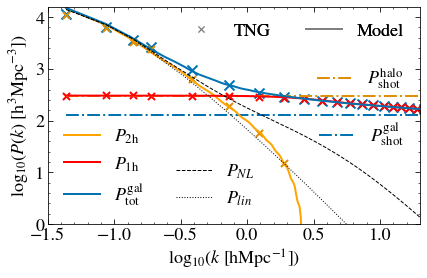

In [117]:

plt.plot(logks_tng, [np.log10((Pk_gal10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{\mathrm{gal}}_{\mathrm{shot}}$", linestyle="dashdot", c=palette_tab10[0])
plt.plot(logks_tng, [np.log10((Pk_sum10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{\mathrm{halo}}_{\mathrm{shot}}$", linestyle="dashdot", c=palette_tab10[1])

#plt.scatter(logks_tng, np.log10((Pk_gal10["power"].real)), label="$P^{\mathrm{gal}}_{\mathrm{tot}}$", s=50, facecolors='none', edgecolors=palette_tab10[0])

#plt.scatter(logks_tng, np.log10((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])), label="$P_{\mathrm{2h}}$", s=50, facecolors='none', edgecolors=palette_tab10[1])

plt.scatter(logks1,tng_tot1,  marker="x", s=100, c=palette_tab10[0])
plt.scatter(logks_new, spaced_tot, marker="x", s=100, c=palette_tab10[0])
plt.scatter(logks1,tng_2halo1, s=50, marker="x", c=palette_tab10[1])
plt.scatter(logks_new, spaced_2halo, marker="x", s=50, c=palette_tab10[1])

#plt.scatter(logks_tng,tng_1halo, label="$P_{\mathrm{1h}}$",  s=50, facecolors='none', edgecolors='r')

plt.scatter(logks1,tng_1halo1,  s=50, marker="x", c="red")
plt.scatter(logks_new, result,  marker="x", s=50, c="red")


plt.plot(logks_tng, np.log10(pk_fit), label="$P_{\mathrm{2h}}$", c="orange", linestyle="solid", linewidth=2)

plt.plot(logks_tng, np.log10(model_1halo), label="$P_{\mathrm{1h}}$", linewidth=2, c="red")

plt.plot(logks_tng, np.log10(model_1halo + pk_fit), label="$P^{\mathrm{gal}}_{\mathrm{tot}}$", linewidth=2, c=palette_tab10[0])

#plt.plot(logks_tng,np.log10((Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])-Pk_gal10.attrs["shotnoise"])), label=" green - Pshot,gal")
plt.plot(logks_tng, np.log10(4*Pnl(10**logks_tng)),c="k", linestyle="dashed", label="$P_{NL}$", linewidth=1)
plt.plot(logks_tng, np.log10(4*Plin(10**logks_tng)),c="k", linestyle="dotted", label="$P_{lin}$", linewidth=1)

#plt.vlines(0.3, ymin=0,ymax=4)
#plt.ylim(0,4.2)
ax = plt.gca()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h[:1], loc="upper right", bbox_to_anchor=(1,0.55))
ax.add_artist(leg)
leg = ax.legend(handles=h[1:2], loc="upper right", bbox_to_anchor=(1,0.8))
ax.add_artist(leg)
leg = ax.legend(handles=h[2:5], loc="lower left")
ax.add_artist(leg)
leg = ax.legend(handles=h[5:], loc="lower left", bbox_to_anchor=(0.3,0))
ax.add_artist(leg)

marker = Line2D([],[],color="grey", marker="x", label="TNG", linewidth=0)
solid_line = Line2D([],[],color="grey", label="Model")

leg = ax.legend(handles=[marker, solid_line], ncol=2)
ax.add_artist(leg)


plt.xlim(-1.5,1.3)
plt.ylim(0, 4.2)

plt.ylabel(r"$\mathrm{log}_{10}( P(k)\ [\mathrm{h^3 Mpc^{-3}}])$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
#plt.savefig("../../figures/ps_components.pdf", format="pdf", bbox_inches="tight")